### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

In [89]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn import metrics

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [20]:
from wordcloud import WordCloud

### Step 2: Load Data

In [6]:
df = pd.read_csv('./data/News.csv', index_col=0)

In [7]:
df.shape

(44919, 5)

In [8]:
df.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### Step 3: Exploaring Data

#### Basic Info

In [10]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': 100 * df.isnull().sum() / len(df),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [11]:
feature_info

,null,null(%),unique,type
title,0,0.000000,38740,object
text,0,0.000000,38657,object
subject,21,0.046751,19,object
date,21,0.046751,2408,object
class,0,0.000000,2,int64


#### Target Distribution

In [14]:
temp = df['class'].value_counts()

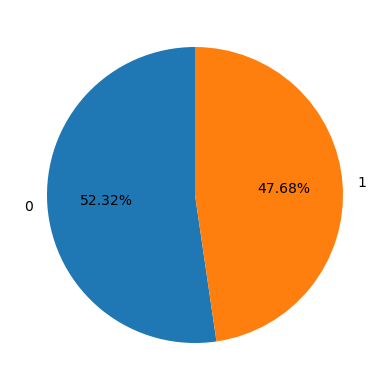

In [17]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    labels=temp.index,
    autopct='%.2f%%',
    startangle=90
)
plt.tight_layout()

### Step 4: Feature Engineering

#### Handling Missing Value

In [18]:
df.drop(['title', 'subject', 'date'], axis=1, inplace=True)

#### Label Encode

In [23]:
df['text'] = df['text'].str.lower()

In [27]:
df['text'] = df['text'].str.replace(r'[^\w\s]', '', regex=True)

In [33]:
stop_words = stopwords.words('english')

In [40]:
df['text'] = df['text'].map(
    lambda x: ' '.join(token for token in x.split() if token not in stop_words)
)

#### Word Cloud

In [54]:
real_consolidated = ' '.join(list(df[df['class'] == 1]['text'].values))
fake_consolidated = ' '.join(list(df[df['class'] == 0]['text'].values))

In [61]:
word_cloud = WordCloud(
    width=1600,
    height=800,
    random_state=21,
    max_font_size=110,
    collocations=False
)

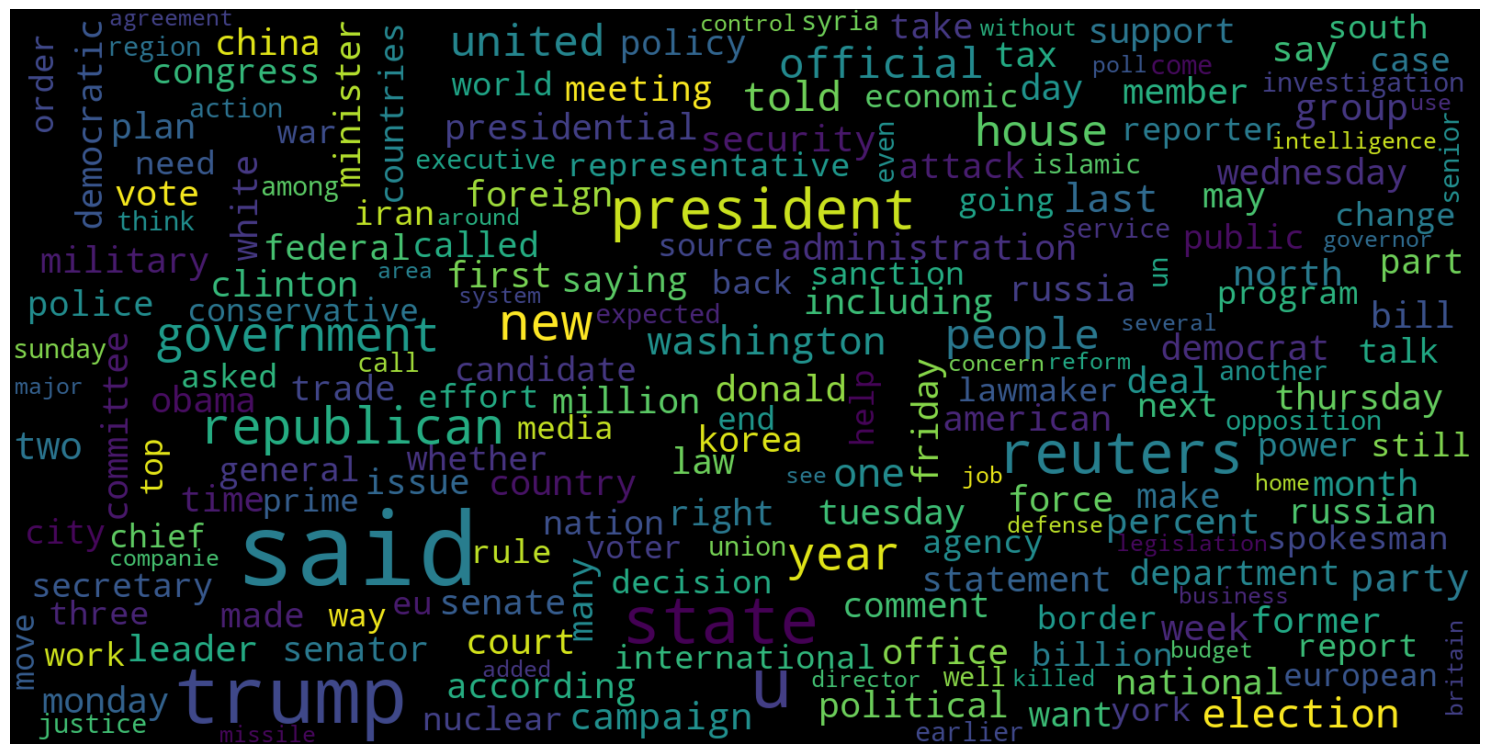

In [62]:
plt.figure(figsize=(15, 10))
plt.imshow(word_cloud.generate(real_consolidated), interpolation='bilinear')
plt.axis('off')
plt.tight_layout()

In [58]:
word_cloud = WordCloud(
    width=1600,
    height=800,
    random_state=21,
    max_font_size=110,
    collocations=False
)

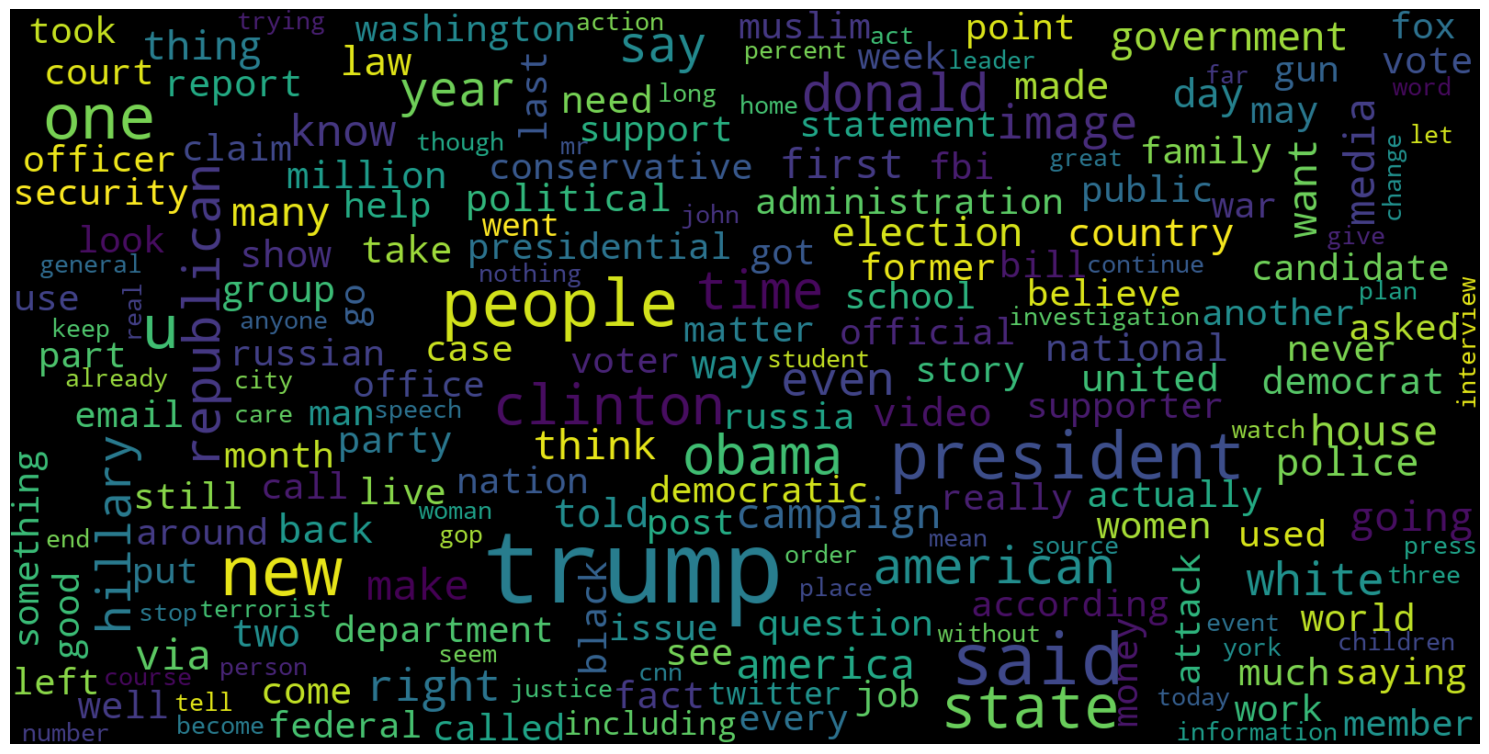

In [59]:
plt.figure(figsize=(15, 10))
plt.imshow(word_cloud.generate(fake_consolidated), interpolation='bilinear')
plt.axis('off')
plt.tight_layout()

In [64]:
vec = CountVectorizer()
bag_of_words = vec.fit_transform(df['text'])

In [77]:
words_freq = pd.DataFrame(
    {
        'word': vec.get_feature_names_out(),
        'count': bag_of_words.sum(axis=0).A1
    }
)

In [81]:
top_words_df = words_freq.sort_values('count', ascending=False).head(20)

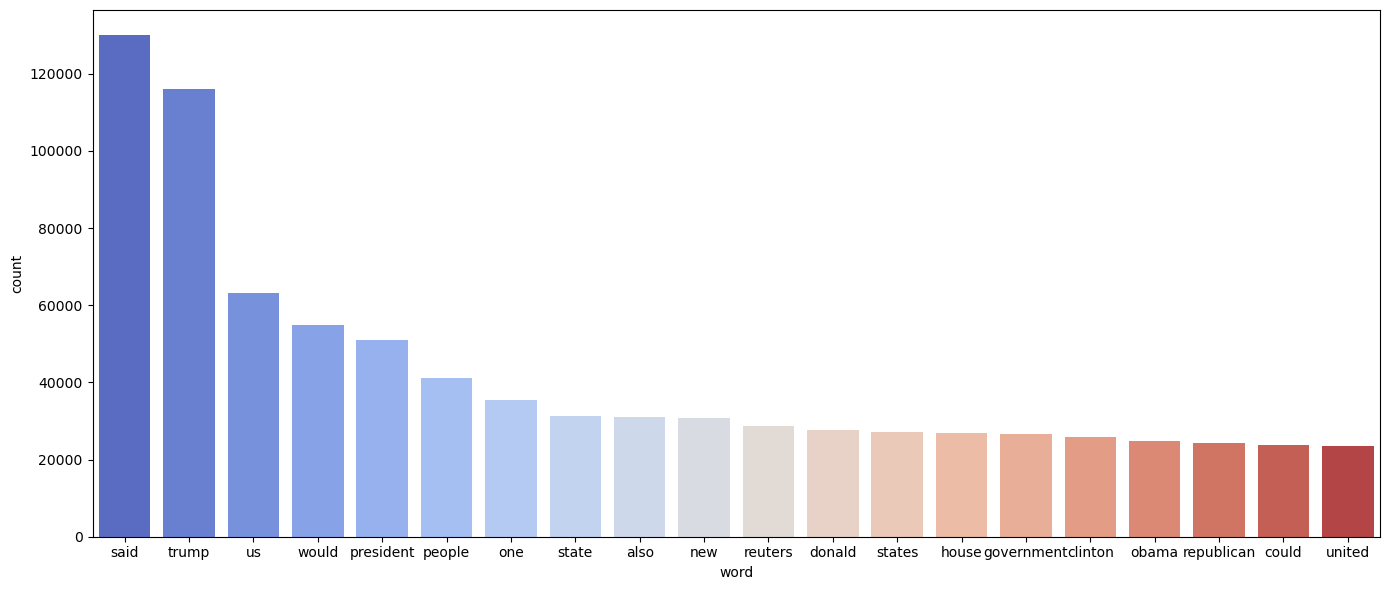

In [87]:
plt.figure(figsize=(14, 6))
sns.barplot(
    x='word',
    y='count',
    data=top_words_df,
    palette='coolwarm'
)
plt.tight_layout()

### Step 5: Preparing Data

#### Split Data

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['class'],
    test_size=0.2,
    random_state=42
)

#### Vectorization

In [122]:
vectorization = TfidfVectorizer()

In [123]:
X_train = vectorization.fit_transform(X_train)
X_test = vectorization.transform(X_test)

### Step 6: Model Development

In [127]:
models = [
    LogisticRegression(),
    DecisionTreeClassifier()
]

In [128]:
for model in models:
    print('-'*20, f'model:{model.__class__.__name__}', '-'*20)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )
    print('training accuracy scores:', [round(x, 3) for x in scores])
    print('training accuracy score:', round(scores.mean(), 3))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('testing accuracy score:', round(metrics.accuracy_score(y_test, y_pred), 3))

-------------------- model:LogisticRegression --------------------
training accuracy scores: [0.987, 0.986, 0.987, 0.987, 0.989]
training accuracy score: 0.987
testing accuracy score: 0.99
-------------------- model:DecisionTreeClassifier --------------------
training accuracy scores: [0.996, 0.997, 0.995, 0.996, 0.996]
training accuracy score: 0.996
testing accuracy score: 0.996


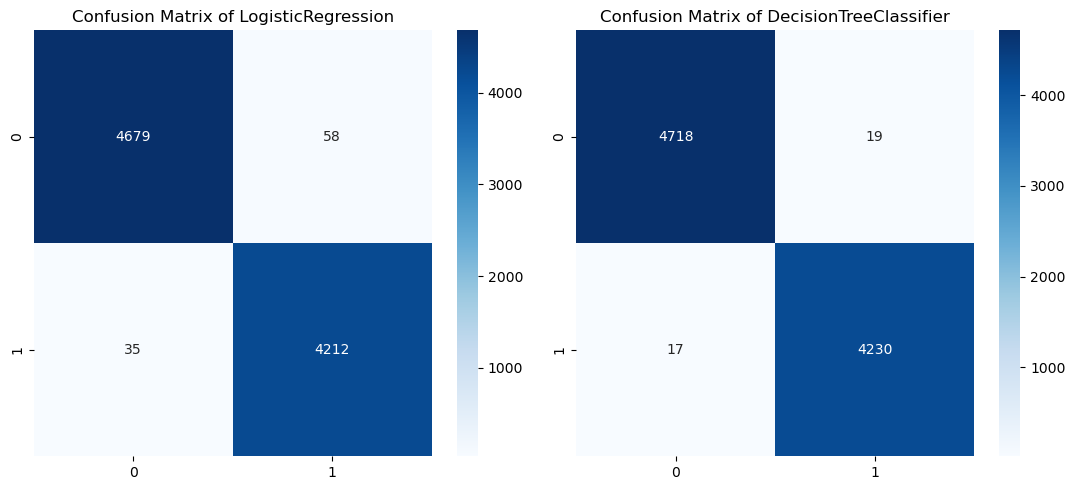

In [132]:
plt.figure(figsize=(11, 5))
for i, model in enumerate(models):
    cm = metrics.confusion_matrix(y_test, model.predict(X_test))
    plt.subplot(1, 2, i+1)
    sns.heatmap(
        cm,
        fmt='d',
        annot=True,
        cmap=plt.cm.Blues
    )
    plt.title(f'Confusion Matrix of {model.__class__.__name__}')
plt.tight_layout()